# Apartado 3. Estudio de los perfiles mensuales de temperatura e irradiación y de los perfiles anuales de precipitación.

**NOTA:** Los perfiles mensuales de una variable se construyen a partir de los 12 valores (medios, medianos, etc.) mensuales de esa variable, uno por cada mes. De manera análoga, los perfiles anuales se construyen a partir de los valores anuales.

## Importación y carga de datos

En esta sección se importan los datos y librerías necesarias para el análisis del Apartado 3.

In [1]:
from carga_de_datos import *

Tamaño de df_orig_temp con los datos cargados: (4383, 15)
Dataframe con todos los datos leidos (filas: días, columnas: variables):
           FECHA  TEMP_CELDA01  TEMP_CELDA02  TEMP_CELDA03  TEMP_CELDA04  \
0     2014-01-01      9.304810      9.234131      9.134725      8.917480   
1     2014-01-02     11.986209     11.888858     11.768883     11.706729   
2     2014-01-03     13.474006     13.405910     13.308051     13.187058   
3     2014-01-04     11.460185     11.400940     11.306010     11.271545   
4     2014-01-05      7.990672      8.004791      7.974009      7.590749   
...          ...           ...           ...           ...           ...   
4378  2025-12-27      6.853189      6.883666      6.892943      6.586832   
4379  2025-12-28      8.640758      8.662160      8.675710      8.074249   
4380  2025-12-29      7.409761      7.522859      7.593782      6.951753   
4381  2025-12-30      8.605798      8.644759      8.652287      7.629785   
4382  2025-12-31      7.655819   

## 3.1. ¿Hay diferencias entre el perfil mensual mediano y el medio de temperatura en la celda 01? Según el perfil mediano, ¿en qué mes se alcanza el valor mínimo? ¿Y el máximo?

In [2]:
print(f"En primer lugar debemos preparar los datos de temperatura (extraer año y mes de la fecha).")
df_temp = df_orig_temp.copy()
df_temp['FECHA'] = pd.to_datetime(df_temp['FECHA'])
df_temp['ANNO'] = df_temp['FECHA'].dt.year
df_temp['MES'] = df_temp['FECHA'].dt.month

print(f"En segundo lugar, debemos calcular el perfil mensual medio y mediano de temperatura en celda 01.")
perfil_medio_temp = df_temp.groupby('MES')['TEMP_CELDA01'].mean()
perfil_mediano_temp = df_temp.groupby('MES')['TEMP_CELDA01'].median()

En primer lugar debemos preparar los datos de temperatura (extraer año y mes de la fecha).
En segundo lugar, debemos calcular el perfil mensual medio y mediano de temperatura en celda 01.


Graficamos los perfiles.


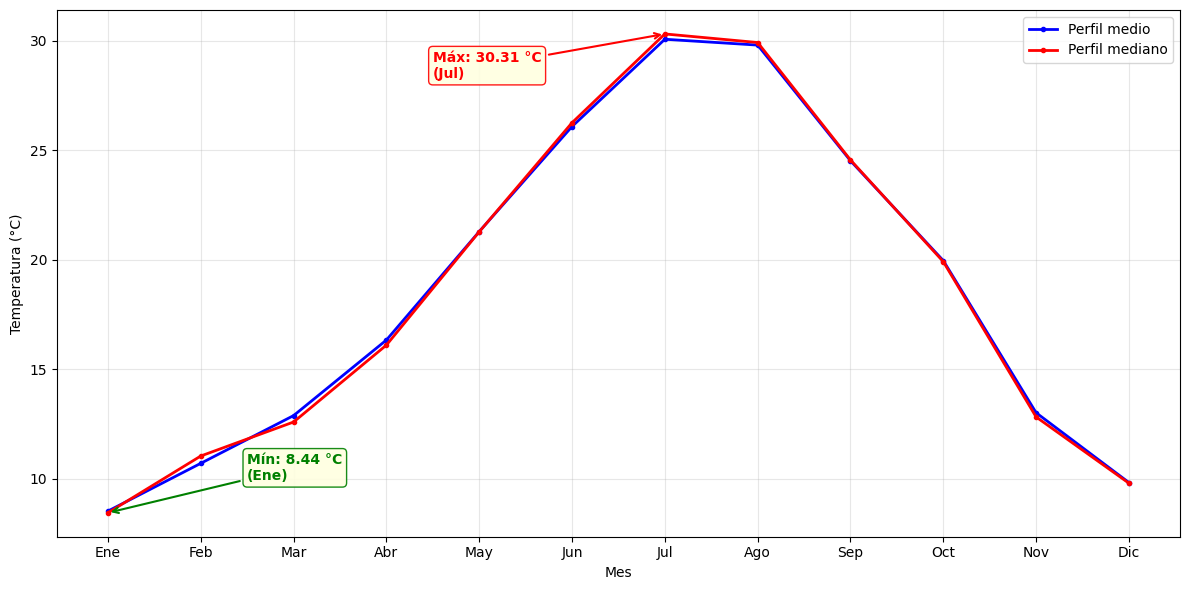

No se aprecian diferencias notables. Se supone que el perfil mediano debería ser menos empinado dado que es menos afectado por los valores atípicos. No se nota necesariamente este comportamiento en las gráficas al compararlas. Es posible que esto ocurra porque los datos de temperatura tienen una distribución poco dispersa y con pocos datos atípicos.


In [3]:
print("Graficamos los perfiles.")

# Calculamos mínimo y máximo del perfil mediano para anotarlos en la gráfica
mes_min = perfil_mediano_temp.idxmin()
mes_max = perfil_mediano_temp.idxmax()
val_min = perfil_mediano_temp[mes_min]
val_max = perfil_mediano_temp[mes_max]

months_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Gráfica con los perfiles mediano y medio de la temperatura
plt.figure(figsize=(12, 6))
plt.plot(perfil_medio_temp.index, perfil_medio_temp.values, 'b.-', label='Perfil medio', linewidth=2)
plt.plot(perfil_mediano_temp.index, perfil_mediano_temp.values, 'r.-', label='Perfil mediano', linewidth=2)

# Anotación del mínimo
plt.annotate(f'Mín: {val_min:.2f} °C\n({months_labels[mes_min-1]})',
             xy=(mes_min, val_min), xytext=(mes_min + 1.5, val_min + 1.5),
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
             fontsize=10, color='green', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='green', alpha=0.9))

# Anotación del máximo
plt.annotate(f'Máx: {val_max:.2f} °C\n({months_labels[mes_max-1]})',
             xy=(mes_max, val_max), xytext=(mes_max - 2.5, val_max - 2),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=10, color='red', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='red', alpha=0.9))

plt.xlabel('Mes')
plt.ylabel('Temperatura (°C)')
plt.xticks(range(1, 13), months_labels)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"No se aprecian diferencias notables. Se supone que el perfil mediano debería ser menos empinado dado que es menos afectado por los valores atípicos. No se nota necesariamente este comportamiento en las gráficas al compararlas. Es posible que esto ocurra porque los datos de temperatura tienen una distribución poco dispersa y con pocos datos atípicos.")

In [4]:
# Declaramos un diccionario con los meses para poder interpretar los resultados de manera más concreta.
months = {n+1:['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'][n] for n in range(12)}

print(f"Por último debemos identificar el mínimo y el máximo según el perfil mediano.")
mes_minimo_temp = perfil_mediano_temp.idxmin()
mes_maximo_temp = perfil_mediano_temp.idxmax()

print(f"  - Mes con temperatura mínima: {mes_minimo_temp}; {months[mes_minimo_temp]} ({perfil_mediano_temp[mes_minimo_temp]:.2f} °C)")
print(f"  - Mes con temperatura máxima: {mes_maximo_temp}; {months[mes_maximo_temp]} ({perfil_mediano_temp[mes_maximo_temp]:.2f} °C)")

Por último debemos identificar el mínimo y el máximo según el perfil mediano.
  - Mes con temperatura mínima: 1; Ene (8.44 °C)
  - Mes con temperatura máxima: 7; Jul (30.31 °C)


## 3.2. Dibuja la evolución mensual de los deciles (p10, p20, …, p90) de la temperatura en la celda 01 en una sola gráfica. Explica lo que observas. ¿La variabilidad de los datos mensuales de temperatura en la celda 01 es la misma para todos los meses?

In [5]:
print(f"Calculamos los deciles mensuales de temperatura (p10, p20, ..., p90)")
deciles_temp = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
perfil_deciles_temp = df_temp.groupby('MES')['TEMP_CELDA01'].quantile(deciles_temp).unstack()
print(f"Perfil de deciles:\n{perfil_deciles_temp}")


Calculamos los deciles mensuales de temperatura (p10, p20, ..., p90)
Perfil de deciles:
           0.1        0.2        0.3        0.4        0.5        0.6  \
MES                                                                     
1     5.076751   6.245031   6.990270   7.787421   8.441033   9.118793   
2     7.304574   8.680383   9.677340  10.424764  11.033793  11.630403   
3     9.440749  10.334664  11.205246  11.807450  12.586017  13.404091   
4    11.944346  13.537730  14.677617  15.391510  16.097824  17.122300   
5    16.221307  17.752954  19.108118  20.200130  21.271682  22.385483   
6    20.783533  22.338965  23.686142  24.897971  26.252868  27.339219   
7    26.830054  28.133467  28.908178  29.544344  30.306224  30.976977   
8    26.513150  27.938130  28.811370  29.322669  29.914022  30.422182   
9    20.599491  21.837331  22.776817  23.803298  24.552450  25.143016   
10   15.439457  16.968386  18.189874  19.106120  19.905909  21.017120   
11    9.274834  10.628430  11.444684

Graficamos la evolución mensual por deciles.


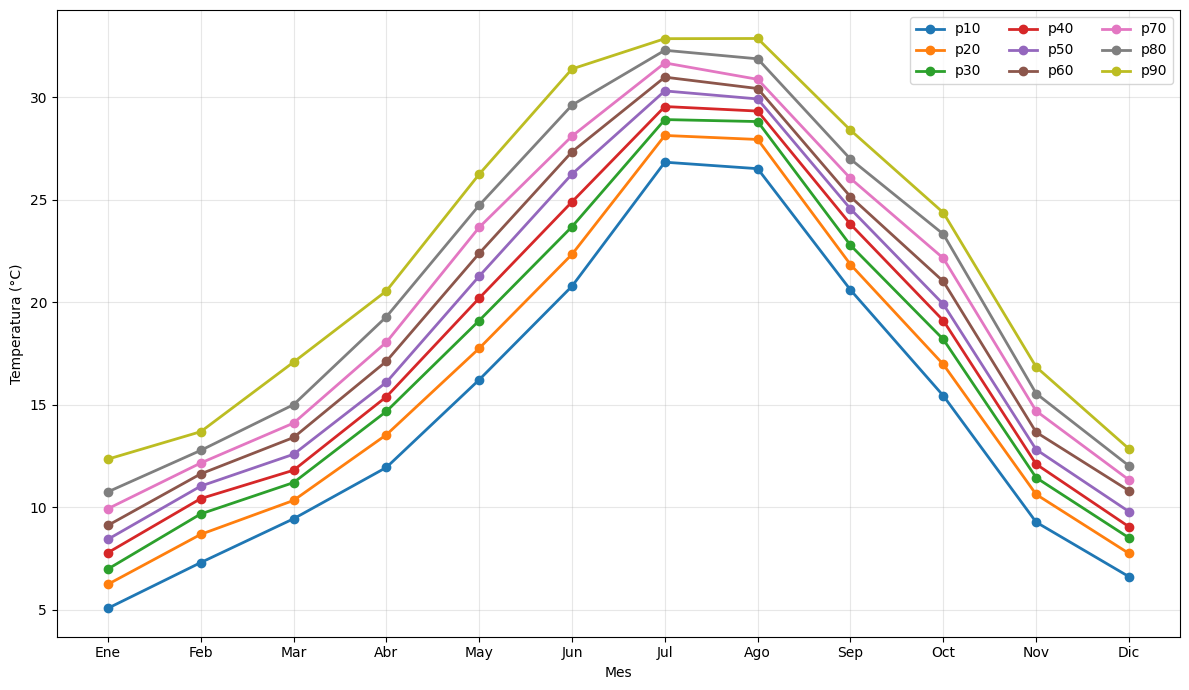

In [6]:
print(f"Graficamos la evolución mensual por deciles.")
# Gráfica con la evolución mensual de deciles (temperatura)

plt.figure(figsize=(12, 7))
for decil in deciles_temp:
    plt.plot(perfil_deciles_temp.index, perfil_deciles_temp[decil], marker='o', label=f'p{int(decil*100)}', linewidth=2)

plt.xlabel('Mes')
plt.ylabel('Temperatura (°C)')
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.legend(loc='best', ncol=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
print(f"Claramente, la evolución no es la misma en todos los meses; en marzo, junio y agosto los deciles 10 y 90 están más alejados del resto. Es posible que esto ocurra porque la temperatura varía más en esos meses y se producen más días con temperatura atípica.")
print(f"De manera opuesta, en febrero, julio, noviembre y diciembre los deciles están más juntos, por lo que se puede inferir que la distribución en estos meses es menos dispersa.")
print(f"\nEstos cambios ocurren, probablemente, porque en los meses en los que varía más la temperatura las estaciones todavía se están asentando y no existe una tendencia clara en el clima. Del mismo modo, en los meses en los que los deciles están más juntos, las estaciones están claramente marcadas y se genera una tendencia climática más estable.")

Claramente, la evolución no es la misma en todos los meses; en marzo, junio y agosto los deciles 10 y 90 están más alejados del resto. Es posible que esto ocurra porque la temperatura varía más en esos meses y se producen más días con temperatura atípica.
De manera opuesta, en febrero, julio, noviembre y diciembre los deciles están más juntos, por lo que se puede inferir que la distribución en estos meses es menos dispersa.

Estos cambios ocurren, probablemente, porque en los meses en los que varía más la temperatura las estaciones todavía se están asentando y no existe una tendencia clara en el clima. Del mismo modo, en los meses en los que los deciles están más juntos, las estaciones están claramente marcadas y se genera una tendencia climática más estable.


## 3.3. Repite los análisis anteriores (puntos 3.1 y 3.2) para la irradiación.

### 3.3.1. Perfil mensual mediano y medio de irradiación en la celda 01

In [8]:
print(f"En primer lugar debemos preparar los datos de irradiación (extraer año y mes de la fecha).")
df_irrad = df_orig_irrad.copy()
df_irrad['FECHA'] = pd.to_datetime(df_irrad['FECHA'])
df_irrad['ANNO'] = df_irrad['FECHA'].dt.year
df_irrad['MES'] = df_irrad['FECHA'].dt.month


En primer lugar debemos preparar los datos de irradiación (extraer año y mes de la fecha).


In [9]:
print(f"En segundo lugar, debemos calcular el perfil mensual medio y mediano de irradiación en celda 01.")
perfil_medio_irrad = df_irrad.groupby('MES')['IRRAD_CELDA01'].mean()
perfil_mediano_irrad = df_irrad.groupby('MES')['IRRAD_CELDA01'].median()

print(f"Por último debemos identificar el mínimo y el máximo según el perfil mediano.")
mes_minimo_irrad = perfil_mediano_irrad.idxmin()
mes_maximo_irrad = perfil_mediano_irrad.idxmax()


En segundo lugar, debemos calcular el perfil mensual medio y mediano de irradiación en celda 01.
Por último debemos identificar el mínimo y el máximo según el perfil mediano.


Graficamos los perfiles.


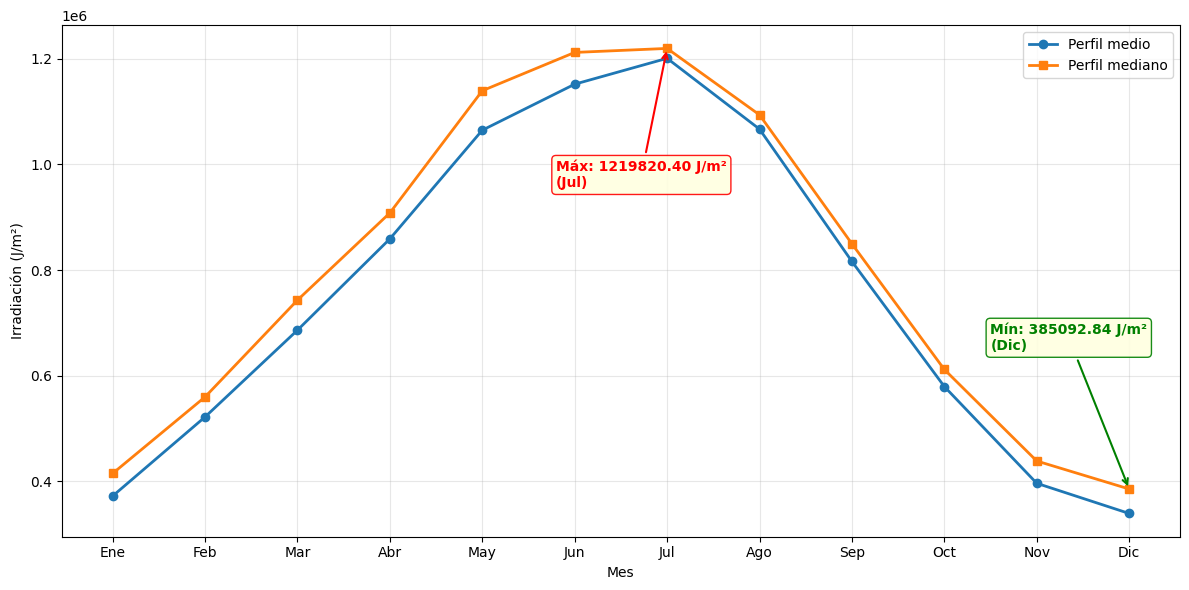

En este caso se aprecia claramente cómo el perfil mediano es superior al perfil medio. Esto se debe a que existen datos atípicos en la parte inferior de la distribución, lo cual hace que el perfil medio sea menor.


In [10]:
print("Graficamos los perfiles.")

# Calculamos mínimo y máximo del perfil mediano para anotarlos en la gráfica
mes_min_irrad = perfil_mediano_irrad.idxmin()
mes_max_irrad = perfil_mediano_irrad.idxmax()
val_min_irrad = perfil_mediano_irrad[mes_min_irrad]
val_max_irrad = perfil_mediano_irrad[mes_max_irrad]

months_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Gráfica con los perfiles mediano y medio de la irradiación
plt.figure(figsize=(12, 6))
plt.plot(perfil_medio_irrad.index, perfil_medio_irrad.values, marker='o', label='Perfil medio', linewidth=2)
plt.plot(perfil_mediano_irrad.index, perfil_mediano_irrad.values, marker='s', label='Perfil mediano', linewidth=2)

# Anotación del mínimo
plt.annotate(f'Mín: {val_min_irrad:.2f} J/m²\n({months_labels[mes_min_irrad-1]})',
             xy=(mes_min_irrad, val_min_irrad), xytext=(-100, 100), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
             fontsize=10, color='green', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='green', alpha=0.9))

# Anotación del máximo
plt.annotate(f'Máx: {val_max_irrad:.2f} J/m²\n({months_labels[mes_max_irrad-1]})',
             xy=(mes_max_irrad, val_max_irrad), xytext=(-80, -100), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=10, color='red', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='red', alpha=0.9))

plt.xlabel('Mes')
plt.ylabel('Irradiación (J/m²)')
plt.xticks(range(1, 13), months_labels)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"En este caso se aprecia claramente cómo el perfil mediano es superior al perfil medio. Esto se debe a que existen datos atípicos en la parte inferior de la distribución, lo cual hace que el perfil medio sea menor.")

In [11]:
print(f"Según el perfil mediano:")
print(f"  - Mes con irradiación mínima: {mes_minimo_irrad}; {months[mes_minimo_irrad]} ({perfil_mediano_irrad[mes_minimo_irrad]:.2f} J/m²)")
print(f"  - Mes con irradiación máxima: {mes_maximo_irrad}; {months[mes_maximo_irrad]} ({perfil_mediano_irrad[mes_maximo_irrad]:.2f} J/m²)")

Según el perfil mediano:
  - Mes con irradiación mínima: 12; Dic (385092.84 J/m²)
  - Mes con irradiación máxima: 7; Jul (1219820.40 J/m²)


### 3.3.2. Evolución mensual de los deciles de irradiación en la celda 01

In [12]:
print(f"Calculamos los deciles mensuales de irradiación (p10, p20, ..., p90)")
deciles_irrad = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
perfil_deciles_irrad = df_irrad.groupby('MES')['IRRAD_CELDA01'].quantile(deciles_irrad).unstack()
print(f"Perfil de deciles:\n{perfil_deciles_irrad}")


Calculamos los deciles mensuales de irradiación (p10, p20, ..., p90)
Perfil de deciles:
             0.1          0.2          0.3          0.4          0.5  \
MES                                                                    
1     176927.696   258311.646   312530.461   375225.668   414513.520   
2     290484.660   401245.216   457386.050   516572.544   559464.940   
3     358680.116   501037.676   586898.220   656772.950   742902.625   
4     550640.095   676062.650   752024.760   834852.250   908136.500   
5     771653.850   896447.388  1000195.540  1083966.240  1139630.600   
6     938726.020  1052232.780  1124917.200  1174591.480  1212219.650   
7    1117805.460  1162698.100  1190773.650  1207489.420  1219820.400   
8     934130.210   990278.360  1037403.010  1069591.420  1093955.750   
9     605323.620   703030.380   775027.685   817326.396   849618.900   
10    333541.270   431397.676   519250.957   582564.144   611559.250   
11    190768.868   245199.440   344530.360   394

Graficamos la evolución mensual por deciles.


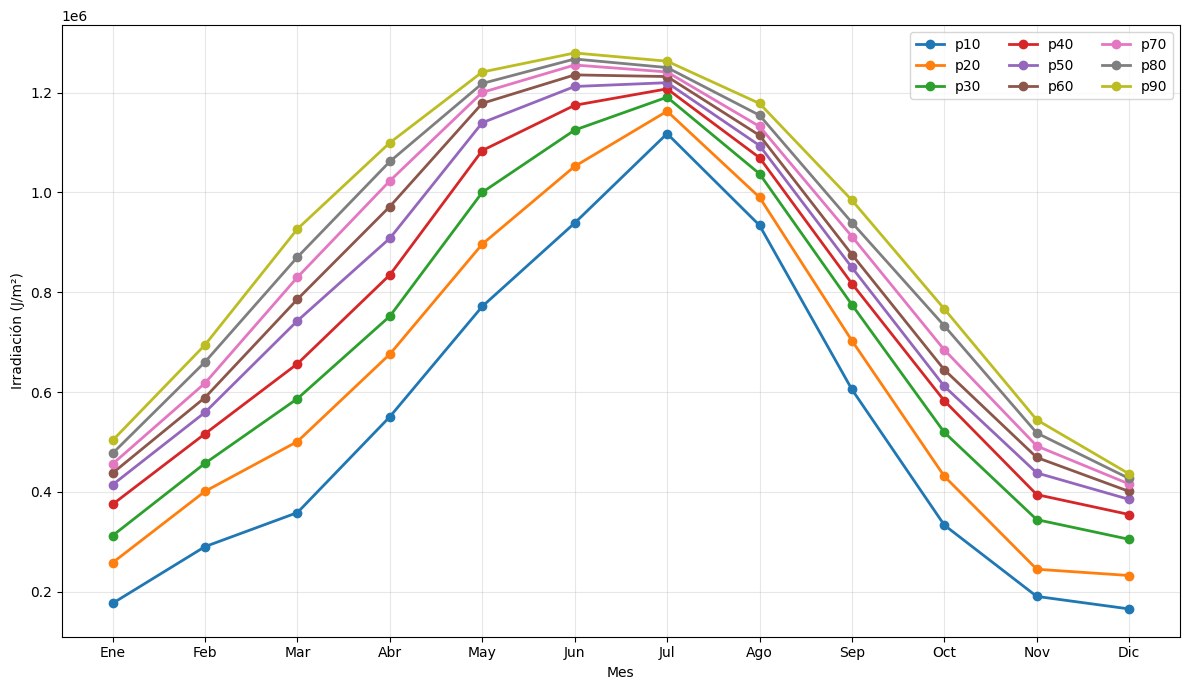

In [13]:
print(f"Graficamos la evolución mensual por deciles.")

# Gráfica con la evolución mensual de deciles (irradiación)
plt.figure(figsize=(12, 7))
for decil in deciles_irrad:
    plt.plot(perfil_deciles_irrad.index, perfil_deciles_irrad[decil], marker='o', label=f'p{int(decil*100)}', linewidth=2)

plt.xlabel('Mes')
plt.ylabel('Irradiación (J/m²)')
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.legend(loc='best', ncol=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
print(f"En este caso, la evolución y la distribución de los deciles en cada mes están más marcadas. Los meses en los que los deciles están más juntos son a partir de julio, siendo este el periodo con menor dispersión.")
print(f"De manera opuesta, de enero a junio los deciles están más separados. La hipótesis de que en algunos meses las estaciones todavía están cambiando se mantiene.")
print(f"\nEn esta distribución se aprecia con claridad cómo, a finales de verano, durante el otoño y al inicio del invierno, la dispersión es menor, lo que sugiere una tendencia climática más estable. En el resto del año, la tendencia está menos definida y aparecen datos atípicos más extremos.")
print(f"Es importante recalcar que los deciles menores (de 10 a 40) están más dispersos que los mayores durante todo el año. Esto indica que los datos por debajo de la mediana están más dispersos que los que están por encima.")

En este caso, la evolución y la distribución de los deciles en cada mes están más marcadas. Los meses en los que los deciles están más juntos son a partir de julio, siendo este el periodo con menor dispersión.
De manera opuesta, de enero a junio los deciles están más separados. La hipótesis de que en algunos meses las estaciones todavía están cambiando se mantiene.

En esta distribución se aprecia con claridad cómo, a finales de verano, durante el otoño y al inicio del invierno, la dispersión es menor, lo que sugiere una tendencia climática más estable. En el resto del año, la tendencia está menos definida y aparecen datos atípicos más extremos.
Es importante recalcar que los deciles menores (de 10 a 40) están más dispersos que los mayores durante todo el año. Esto indica que los datos por debajo de la mediana están más dispersos que los que están por encima.


## 3.4. Dibuja la evolución anual de los deciles (p10, p20, …, p90) de la precipitación en la celda 01 en una sola gráfica. Explica lo que observas. Según el perfil anual mediano, ¿qué año ha sido más seco? ¿Y más húmedo? ¿Cambia la variabilidad de los datos anuales con los años?

In [15]:
print(f"En primer lugar debemos preparar los datos de precipitación (extraer año de la fecha).")
df_precip = df_orig_precip.copy()
df_precip['FECHA'] = pd.to_datetime(df_precip['FECHA'])
df_precip['ANNO'] = df_precip['FECHA'].dt.year


En primer lugar debemos preparar los datos de precipitación (extraer año de la fecha).


In [16]:
print(f"En segundo lugar, calculamos los deciles anuales de precipitación (p10, p20, ..., p90).")
deciles_precip = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
perfil_deciles_precip = df_precip.groupby('ANNO')['PRECIP_CELDA01'].quantile(deciles_precip).unstack()
print(f"Perfil de deciles:\n{perfil_deciles_precip}")

print(f"Por último, calculamos el perfil anual mediano para identificar año más seco y más húmedo.")
perfil_mediano_precip = df_precip.groupby('ANNO')['PRECIP_CELDA01'].median()
anno_seco = perfil_mediano_precip.idxmin()
anno_humedo = perfil_mediano_precip.idxmax()

print(f"Según el perfil anual mediano:")
print(f"  - Año más seco: {anno_seco} ({perfil_mediano_precip[anno_seco]:.4f} mm)")
print(f"  - Año más húmedo: {anno_humedo} ({perfil_mediano_precip[anno_humedo]:.4f} mm)")

En segundo lugar, calculamos los deciles anuales de precipitación (p10, p20, ..., p90).
Perfil de deciles:
               0.1           0.2           0.3           0.4           0.5  \
ANNO                                                                         
2014  0.000000e+00  1.837810e-08  3.588174e-08  7.162487e-08  1.084919e-07   
2015  0.000000e+00  1.812974e-08  3.566344e-08  5.190508e-08  7.196017e-08   
2016  0.000000e+00  3.551443e-08  3.583899e-08  5.403149e-08  7.984247e-08   
2017  0.000000e+00  1.806935e-08  3.551443e-08  3.583196e-08  6.609285e-08   
2018  9.095917e-09  3.568144e-08  5.371182e-08  9.023551e-08  4.242640e-07   
2019  0.000000e+00  1.812974e-08  3.576279e-08  5.411566e-08  7.231691e-08   
2020  0.000000e+00  1.812974e-08  3.576279e-08  5.525756e-08  1.075434e-07   
2021  0.000000e+00  1.817418e-08  3.576279e-08  6.977468e-08  9.922174e-08   
2022  1.775722e-08  3.551443e-08  3.636319e-08  6.552785e-08  9.342349e-08   
2023  0.000000e+00  3.550935e-08  3

Graficamos la evolución anual por deciles.


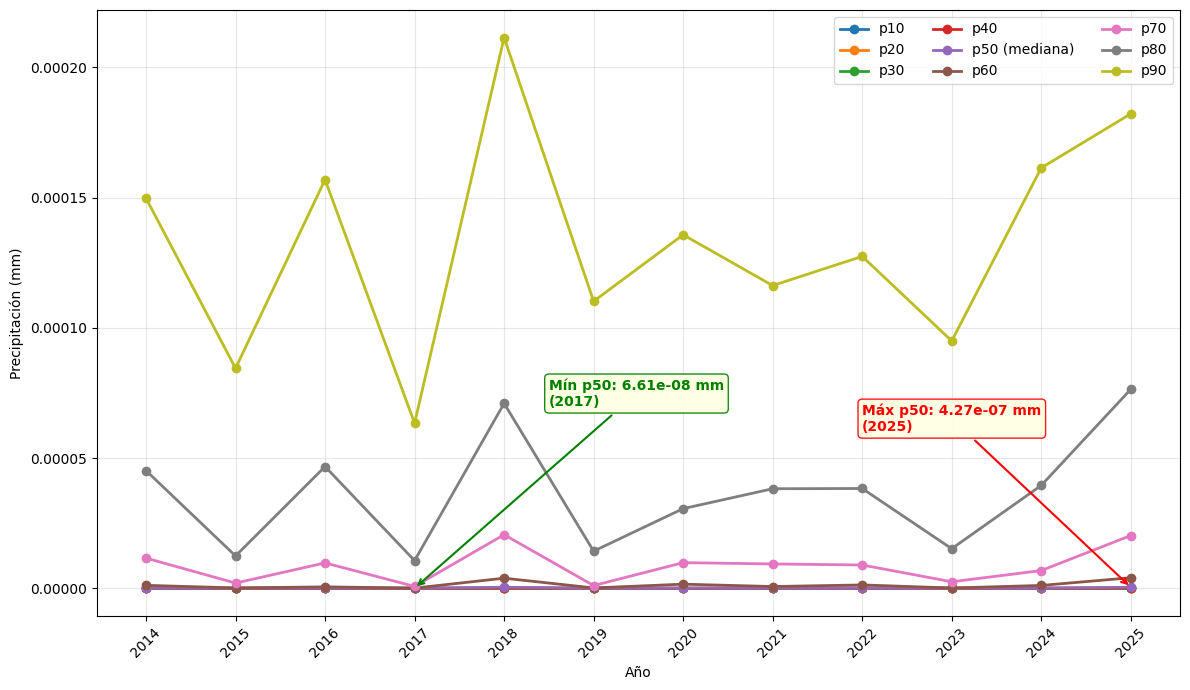

In [17]:
print(f"Graficamos la evolución anual por deciles.")

# Calculamos mín y máx del perfil mediano (p50) para anotarlos
anno_min_p50 = perfil_deciles_precip[0.5].idxmin()
anno_max_p50 = perfil_deciles_precip[0.5].idxmax()
val_min_p50 = perfil_deciles_precip[0.5][anno_min_p50]
val_max_p50 = perfil_deciles_precip[0.5][anno_max_p50]

# Gráfica con la evolución anual de deciles (precipitación)
plt.figure(figsize=(12, 7))
for decil in deciles_precip:
    lbl = f"p{int(decil*100)} (mediana)" if decil == 0.5 else f"p{int(decil*100)}"
    plt.plot(perfil_deciles_precip.index, perfil_deciles_precip[decil], marker='o', label=lbl, linewidth=2)

# Anotación del mínimo del p50
plt.annotate(f"Mín p50: {val_min_p50:.2e} mm\n({anno_min_p50})",
             xy=(anno_min_p50, val_min_p50),
             xytext=(anno_min_p50 + 1.5, val_min_p50 + 0.00007),
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
             fontsize=10, color='green', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='green', alpha=0.9))

# Anotación del máximo del p50
plt.annotate(f"Máx p50: {val_max_p50:.2e} mm\n({anno_max_p50})",
             xy=(anno_max_p50, val_max_p50),
             xytext=(anno_max_p50 - 3, val_max_p50 + 0.00006),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=10, color='red', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='red', alpha=0.9))

plt.xlabel('Año')
plt.ylabel('Precipitación (mm)')
plt.xticks(perfil_deciles_precip.index, rotation=45)
plt.legend(loc='best', ncol=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Graficamos la evolución anual por deciles con una escala logarítmica para que se aprecien los deciles menores.


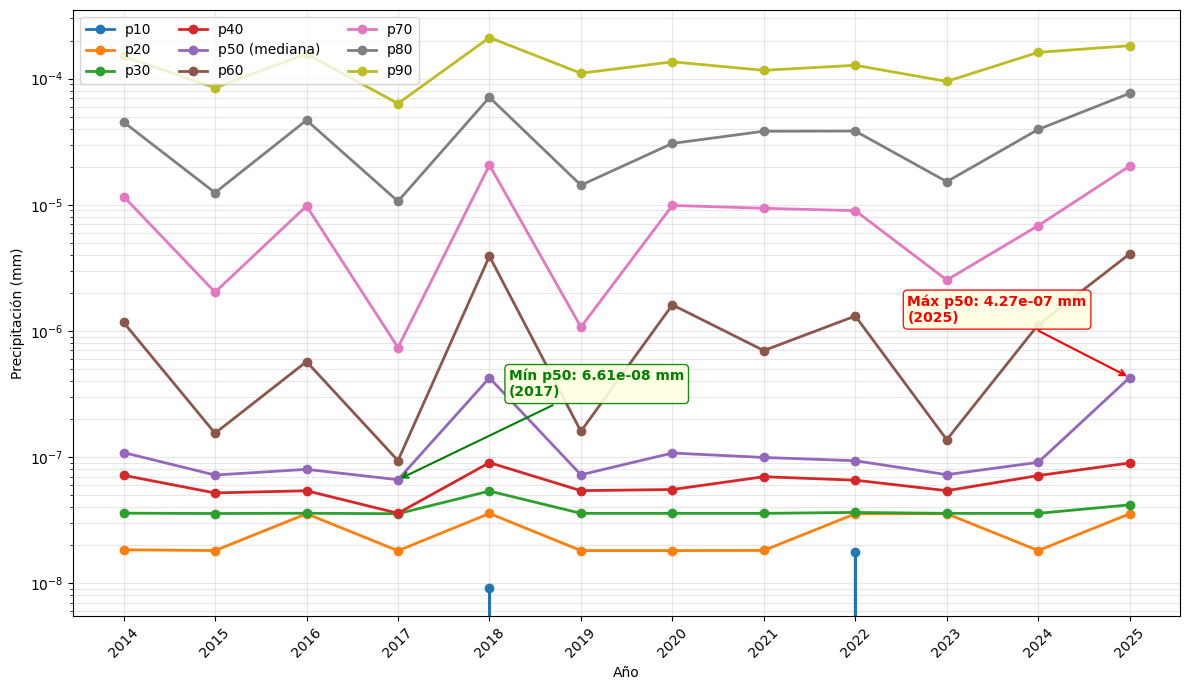

In [18]:
print(f"Graficamos la evolución anual por deciles con una escala logarítmica para que se aprecien los deciles menores.")

# Gráfica con la evolución anual de deciles en escala logarítmica (precipitación)
plt.figure(figsize=(12, 7))
for decil in deciles_precip:
    lbl = f"p{int(decil*100)} (mediana)" if decil == 0.5 else f"p{int(decil*100)}"
    plt.plot(perfil_deciles_precip.index, perfil_deciles_precip[decil], marker='o', label=lbl, linewidth=2)

# Anotación del mínimo del p50
plt.annotate(f"Mín p50: {val_min_p50:.2e} mm\n({anno_min_p50})",
             xy=(anno_min_p50, val_min_p50),
             xytext=(80, 60), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
             fontsize=10, color='green', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='green', alpha=0.9))

# Anotación del máximo del p50
plt.annotate(f"Máx p50: {val_max_p50:.2e} mm\n({anno_max_p50})",
             xy=(anno_max_p50, val_max_p50),
             xytext=(-160, 40), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=10, color='red', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='red', alpha=0.9))

plt.yscale('log')
plt.xlabel('Año')
plt.ylabel('Precipitación (mm)')
plt.xticks(perfil_deciles_precip.index, rotation=45)
plt.legend(loc='best', ncol=3)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

In [19]:
print(f"Según el perfil anual mediano:")
print(f"  - Año más seco: {anno_seco} ({perfil_mediano_precip[anno_seco]:.2e} mm)")
print(f"  - Año más húmedo: {anno_humedo} ({perfil_mediano_precip[anno_humedo]:.2e} mm)")

Según el perfil anual mediano:
  - Año más seco: 2017 (6.61e-08 mm)
  - Año más húmedo: 2025 (4.27e-07 mm)


In [20]:
print(f"Claramente existe una importante variabilidad con los años. Los datos están más dispersos en los años 2016 y 2018.")
print(f"\nEl perfil mediano nos indica que la precipitación aumentó de manera significativa en dichos años. Estos cambios bruscos tienden a provocar una variación mayor en los datos, lo cual se aprecia claramente en la gráfica de escala logarítmica. En ésta se observa que en 2019, 2021 y 2023 hubo un nivel de precipitación más estable, mientras que en 2016, 2018 y 2025 hubo un aumento y con él un incremento en la dispersión de los datos. Este comportamiento de los datos es exactamente opuesto al de la irradiación.")
print(f"Se podría afirmar que la dispersión de los datos en la precipitación es directamente proporcional al incremento medio/mediano de la propia precipitación, mientras que de manera opuesta; la dispersión de los datos en la irradiación es inversamente proporcional al incremento medio/mediano de la propia irradiación (ver sub-apartado anterior).")

Claramente existe una importante variabilidad con los años. Los datos están más dispersos en los años 2016 y 2018.

El perfil mediano nos indica que la precipitación aumentó de manera significativa en dichos años. Estos cambios bruscos tienden a provocar una variación mayor en los datos, lo cual se aprecia claramente en la gráfica de escala logarítmica. En ésta se observa que en 2019, 2021 y 2023 hubo un nivel de precipitación más estable, mientras que en 2016, 2018 y 2025 hubo un aumento y con él un incremento en la dispersión de los datos. Este comportamiento de los datos es exactamente opuesto al de la irradiación.
Se podría afirmar que la dispersión de los datos en la precipitación es directamente proporcional al incremento medio/mediano de la propia precipitación, mientras que de manera opuesta; la dispersión de los datos en la irradiación es inversamente proporcional al incremento medio/mediano de la propia irradiación (ver sub-apartado anterior).
